# Visualize SCALP-lite Embedding

Load optimized parameters saved by notebook 01 when available; otherwise use the selected dataset defaults. Then run the embedding, plot it, and save the embedded AnnData file for evaluation.


In [1]:
from scalp_lite.notebook_utils import (
    DATASET_REGISTRY,
    dataset_config,
    embed_dataset,
    load_or_default_params,
    load_preprocessed_data,
    make_estimator,
)


selected_dataset = "zebrafish"
dataset = dataset_config(selected_dataset)
optimized_params = load_or_default_params(selected_dataset, dataset)

# Use saved/default preprocessing settings; max_cells can be increased for final visualization.
preprocess_overrides = {
    **optimized_params.get("preprocess_params", {}),
    "max_cells": 6000,
}
estimator_params = optimized_params.get("estimator_params", {})
graph_params = optimized_params["graph_params"]

estimator = make_estimator(dataset, random_state=0, **estimator_params)
input_path = dataset["input_path"]
output_path = dataset["output_path"]
batch_key = dataset["batch_key"]
label_key = dataset["label_key"]

selected_dataset, optimized_params["source"], input_path, output_path, batch_key, label_key


('zebrafish',
 'optimized',
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/cellrank-zebrafish.h5ad'),
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/cellrank-zebrafish-scalp.h5ad'),
 'Stage',
 'lineages')

In [2]:
optimized_params


{'dataset': 'zebrafish',
 'estimator_params': {'n_components': 57},
 'graph_params': {'assignment_quantile': 0.8796496635623955,
  'edge_weighting': 'distance',
  'hubness_correction': 'csls',
  'hubness_k': 9,
  'intra_fraction': 0.8745489182481548,
  'metric': 'euclidean',
  'mutual_neighbors': True,
  'n_inter_edges': 2,
  'n_neighbors': 28,
  'neighbor_mode': 'distance',
  'rank_correction': True,
  'symmetrize': True},
 'metadata': {'best_model': 'gplvm',
  'best_score': 0.8995500000000001,
  'fixed_preprocess_params': {'max_cells': 1000},
  'gplvm_best_score': 0.8995500000000001,
  'pca_best_score': 0.8795499999999999,
  'random_state': 0},
 'preprocess_params': {'create_artificial_batch': False,
  'hvg_flavor': 'variance',
  'max_cells': 1000,
  'min_cell_genes': None,
  'min_gene_counts': 3,
  'n_top_genes': 1129,
  'normalize': False},
 'source': 'optimized',
 'path': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/optimized_params/zebrafish_graph_param

In [3]:
adata = load_preprocessed_data(estimator, dataset, **preprocess_overrides)
adata


AnnData object with n_obs × n_vars = 2434 × 1129
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    var: 'scalp_lite_hvg_score', 'scalp_lite_selected'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors'
    obsm: 'X_force_directed', 'X_pca'

In [4]:
adata = embed_dataset(adata, estimator, graph_params)
graph_params


{'assignment_quantile': 0.8796496635623955,
 'edge_weighting': 'distance',
 'hubness_correction': 'csls',
 'hubness_k': 9,
 'intra_fraction': 0.8745489182481548,
 'metric': 'euclidean',
 'mutual_neighbors': True,
 'n_inter_edges': 2,
 'n_neighbors': 28,
 'neighbor_mode': 'distance',
 'rank_correction': True,
 'symmetrize': True}

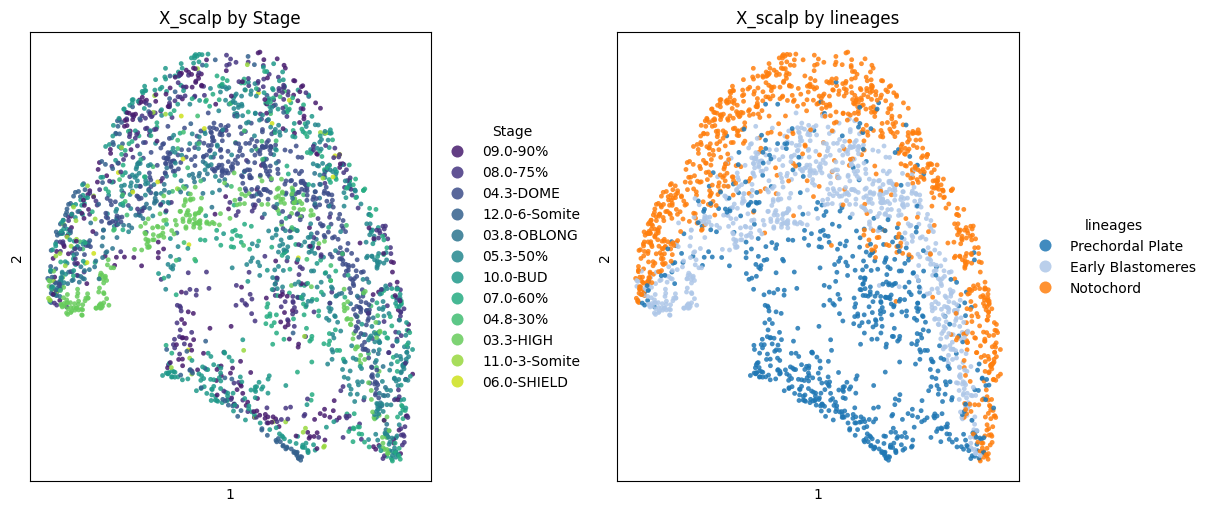

In [5]:
estimator.plot(adata, embedding_key="X_scalp");


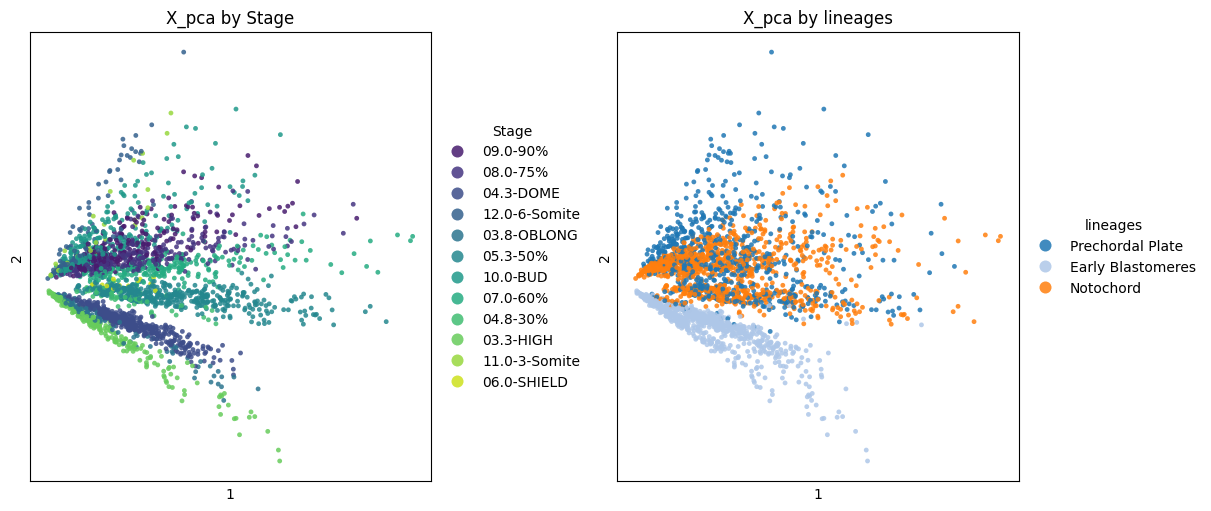

In [6]:
estimator.plot(adata, embedding_key="X_pca");


In [7]:
estimator.save(adata, output_path)
output_path


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/cellrank-zebrafish-scalp.h5ad')